# Étape 3 — Clustering K-Means

Ce notebook applique le clustering K-Means sur le dataset diabète standardisé.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
from imblearn.over_sampling import RandomOverSampler

## 1. Chargement des données standardisées

In [51]:
df_scaled = pd.read_csv('../data/dataset-diabete-standardise.csv')
df_origine=pd.read_csv("../data/dataset-diabete-nettoye.csv")


print(f'Dimensions : {df_scaled.shape}')
print(f'Colonnes : {list(df_scaled.columns)}')
df_scaled.head()

Dimensions : (768, 8)
Colonnes : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.647150,0.863399,-0.036767,0.704209,0.651174,0.183445,0.588927,1.445691
1,-0.848970,-1.206602,-0.544319,0.051424,-0.916973,-0.864347,-0.378101,-0.189304
2,1.245598,2.013400,-0.713503,-0.318488,0.935593,-1.358306,0.746595,-0.103252
3,-0.848970,-1.075174,-0.544319,-0.601361,-0.655615,-0.639820,-1.022787,-1.049828
4,-1.148194,0.501970,-2.743711,0.704209,0.292448,1.605449,2.596563,-0.017199


## 2. Méthode du Coude (Elbow) + Score Silhouette

On teste k de 2 à 10 pour trouver le nombre optimal de clusters.

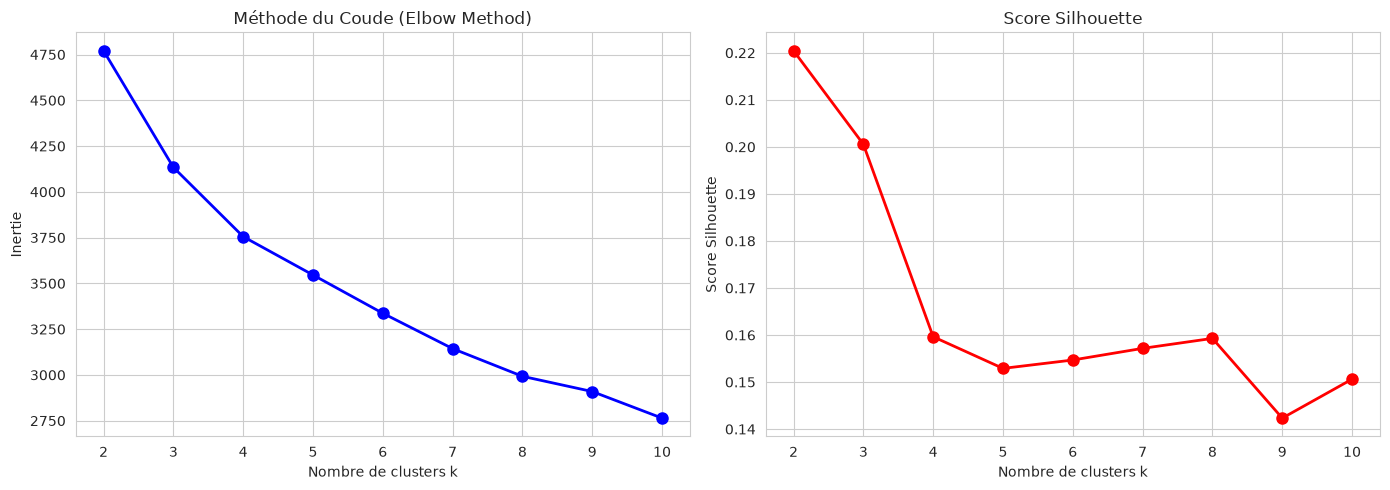


Scores Silhouette par k :
  k=2 : 0.2204
  k=3 : 0.2005
  k=4 : 0.1596
  k=5 : 0.1529
  k=6 : 0.1547
  k=7 : 0.1572
  k=8 : 0.1593
  k=9 : 0.1423
  k=10 : 0.1506


In [52]:
inertias = []
silhouettes = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_scaled, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Nombre de clusters k')
ax1.set_ylabel('Inertie')
ax1.set_title('Méthode du Coude (Elbow Method)')
ax1.set_xticks(list(K))

ax2.plot(K, silhouettes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Nombre de clusters k')
ax2.set_ylabel('Score Silhouette')
ax2.set_title('Score Silhouette')
ax2.set_xticks(list(K))

plt.tight_layout()
plt.show()

print('\nScores Silhouette par k :')
for k, s in zip(K, silhouettes):
    print(f'  k={k} : {s:.4f}')



## 3. Entraînement du modèle K-Means final

> Modifie `k_optimal` selon les courbes ci-dessus.

In [53]:
k_optimal = 2  # À ajuster selon les courbes

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_origine['Cluster'] = kmeans.fit_predict(df_scaled)
print(f'k optimal choisi : {k_optimal}')
print(f'Inertie finale   : {kmeans.inertia_:.2f}')
print(f'Score Silhouette : {silhouette_score(df_scaled, kmeans.labels_):.4f}')

k optimal choisi : 2
Inertie finale   : 4770.88
Score Silhouette : 0.2204


## 4. Ajout de la colonne Cluster au dataset

In [54]:
df_scaled['Cluster'] = kmeans.labels_

print('Répartition des observations par cluster :')
print(df_scaled['Cluster'].value_counts().sort_index())

Répartition des observations par cluster :
Cluster
0    315
1    453
Name: count, dtype: int64


## 5. Visualisation des clusters

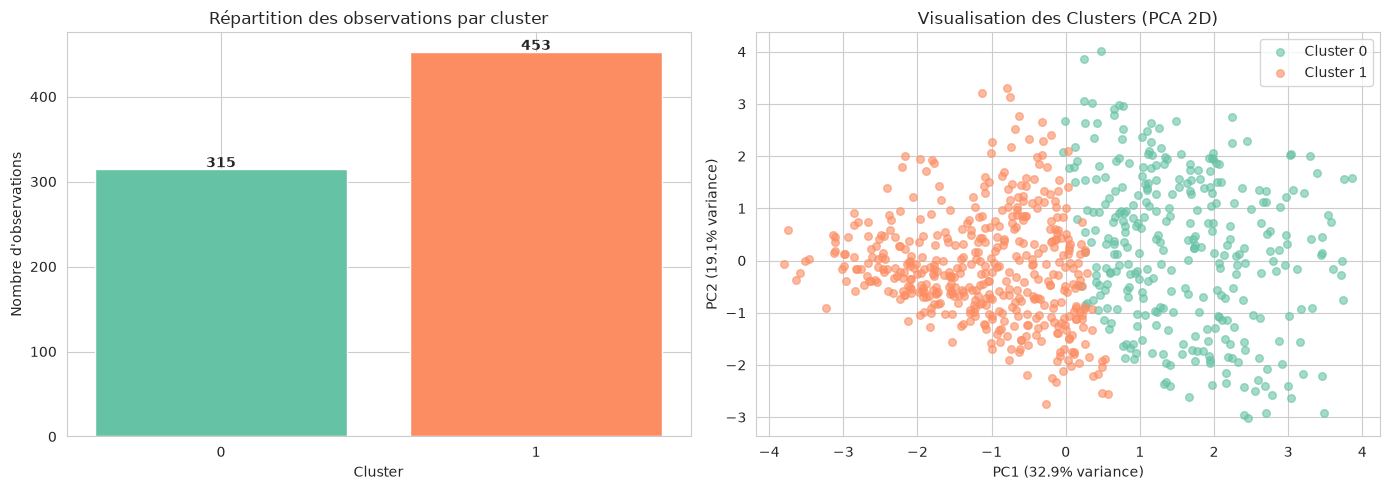

In [55]:
# --- Barplot : répartition par cluster ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df_scaled['Cluster'].value_counts().sort_index()
colors = sns.color_palette('Set2', k_optimal)

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel("Nombre d'observations")
axes[0].set_title('Répartition des observations par cluster')
axes[0].set_xticks(range(k_optimal))
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# --- Scatter PCA 2D ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled.drop(columns=['Cluster']))

for cluster in range(k_optimal):
    mask = kmeans.labels_ == cluster
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f'Cluster {cluster}',
                    color=colors[cluster], alpha=0.6, s=30)

axes[1].set_title('Visualisation des Clusters (PCA 2D)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Interprétation des clusters

Analyse des moyennes par cluster pour comprendre le profil de chaque groupe.

Moyennes des variables par cluster (données standardisées) :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,5.346,143.816,79.312,33.684,199.849,36.105,0.505,40.163
1,2.788,106.360,67.652,24.941,107.154,29.781,0.427,28.358


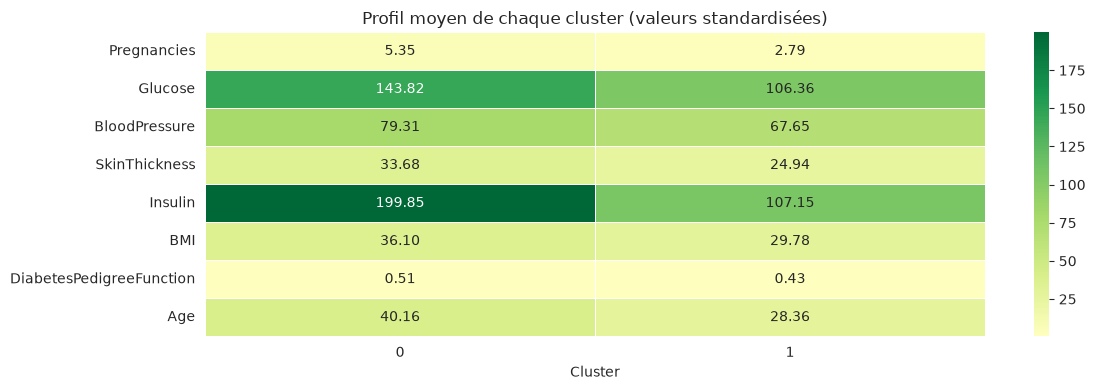

In [56]:
cluster_means = df_origine.groupby('Cluster').mean(numeric_only=True).round(3)
print('Moyennes des variables par cluster (données standardisées) :')
display(cluster_means)

# Heatmap des profils
plt.figure(figsize=(12, 4))
sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5)
plt.title('Profil moyen de chaque cluster (valeurs standardisées)')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

en calcule combein des personne touver à chaque groupe

In [81]:
print(df_origine.groupby('Cluster').size())


Cluster
0    315
1    453
dtype: int64


maintenat partie de determination risque

In [82]:
cluster_means=df_origine.groupby('Cluster')[['Glucose','BMI','DiabetesPedigreeFunction']].mean().round(3)

hight_risk=(
    (cluster_means['Glucose']>126)&
    (cluster_means['BMI']>30)&
    (cluster_means['DiabetesPedigreeFunction']>0.5)
    
)

categories=['risque_eleve','Moderé']
x = cluster_means.index[hight_risk]

df_origine['risk_category']=np.where(
    df_origine['Cluster'].isin(x),
    'risque_eleve','Moderé'
)
    

print(df_origine.head())
    
    






   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    196.0  33.6   
1          1.0     85.0           66.0           29.0     73.6  26.6   
2          8.0    183.0           64.0           25.6    218.2  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  Cluster risk_category  
0                     0.627  50.0        0  risque_eleve  
1                     0.351  31.0        1        Moderé  
2                     0.672  32.0        0  risque_eleve  
3                     0.167  21.0        1        Moderé  
4                     1.200  33.0        1        Moderé  


In [88]:


# Sauvegarde du dataset avec clusters pour Classification.ipynb
df_origine.to_csv('../data/dataset-diabete-clusters.csv', index=False)
print("Dataset avec clusters sauvegarde")
print(df_origine[['Glucose','BMI','DiabetesPedigreeFunction','Cluster']].head())


Dataset avec clusters sauvegarde
   Glucose   BMI  DiabetesPedigreeFunction  Cluster
0    148.0  33.6                     0.627        0
1     85.0  26.6                     0.351        1
2    183.0  23.3                     0.672        0
3     89.0  28.1                     0.167        1
4    137.0  43.1                     1.200        1


In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42
)
print(Y_train.value_counts())

Cluster
1    369
0    245
Name: count, dtype: int64


In [62]:
ros = RandomOverSampler(random_state=42)

X_res, y_res = ros.fit_resample(
    X_train.to_numpy(),
    Y_train.to_numpy()
)
X_train_resampled = pd.DataFrame(X_res, columns=X_train.columns)
y_train_resampled = pd.Series(y_res, name=Y_train.name)
print(y_train_resampled.value_counts())

Cluster
1    369
0    369
Name: count, dtype: int64


Modele Decision TRee

In [63]:
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier(random_state=42)
model1.fit(X_train_resampled, y_train_resampled)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

Modele randome forrest

In [64]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(random_state=42)
model2.fit(X_train_resampled, y_train_resampled)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

regression logistic


In [65]:
from sklearn.linear_model import LogisticRegression

model3 = LogisticRegression(max_iter=1000)
model3.fit(X_train_resampled, y_train_resampled)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

Predictions

In [84]:
y_pred_tree = model1.predict(X_test)

y_pred_rf = model2.predict(X_test)

y_pred_lr = model3.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Decision Tree")
print("Accuracy :", accuracy_score(Y_test, y_pred_tree))
print("Precision:", precision_score(Y_test, y_pred_tree))
print("Recall   :", recall_score(Y_test, y_pred_tree))
print("F1       :", f1_score(Y_test, y_pred_tree))

print("Random forrest")
print("Accuracy :", accuracy_score(Y_test, y_pred_rf))
print("Precision:", precision_score(Y_test, y_pred_rf))
print("Recall   :", recall_score(Y_test, y_pred_rf))
print("F1       :", f1_score(Y_test, y_pred_rf))
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("logistique regression")
print("Accuracy :", accuracy_score(Y_test, y_pred_lr))
print("Precision:", precision_score(Y_test, y_pred_lr))
print("Recall   :", recall_score(Y_test, y_pred_lr))
print("F1       :", f1_score(Y_test, y_pred_lr))

Decision Tree
Accuracy : 0.8181818181818182
Precision: 0.7978723404255319
Recall   : 0.8928571428571429
F1       : 0.8426966292134831
Random forrest
Accuracy : 0.8116883116883117
Precision: 0.8089887640449438
Recall   : 0.8571428571428571
F1       : 0.8323699421965318
logistique regression
Accuracy : 0.8311688311688312
Precision: 0.8372093023255814
Recall   : 0.8571428571428571
F1       : 0.8470588235294118


---
## 7. Optimisation des hyperparamètres (GridSearchCV / RandomizedSearchCV)

On affine les hyperparamètres des trois modèles pour maximiser le F1-score macro.

In [70]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings("ignore")

# Validation croisee stratifiee (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 7.1 Decision Tree — GridSearchCV

In [71]:
param_grid_dt = {
    "max_depth"        : [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "criterion"        : ["gini", "entropy"]
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
gs_dt.fit(X_train_resampled, y_train_resampled)

print("Meilleurs hyperparametres (Decision Tree) :")
print(gs_dt.best_params_)
print(f"Meilleur F1-macro CV : {gs_dt.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Meilleurs hyperparametres (Decision Tree) :
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Meilleur F1-macro CV : 0.8121


### 7.2 Random Forest — RandomizedSearchCV

In [72]:
from scipy.stats import randint

param_dist_rf = {
    "n_estimators"     : randint(50, 300),
    "max_depth"        : [3, 5, 7, 10, None],
    "min_samples_split": randint(2, 11),
    "min_samples_leaf" : randint(1, 5),
    "max_features"     : ["sqrt", "log2", None]
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist_rf,
    n_iter=50,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rs_rf.fit(X_train_resampled, y_train_resampled)

print("Meilleurs hyperparametres (Random Forest) :")
print(rs_rf.best_params_)
print(f"Meilleur F1-macro CV : {rs_rf.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Meilleurs hyperparametres (Random Forest) :
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 183}
Meilleur F1-macro CV : 0.8462


### 7.3 Regression Logistique — GridSearchCV

In [73]:
param_grid_lr = {
    "C"      : [0.001, 0.01, 0.1, 1, 10, 100],
    "solver" : ["lbfgs", "liblinear"],
    "penalty": ["l2"]
}

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid_lr,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
gs_lr.fit(X_train_resampled, y_train_resampled)

print("Meilleurs hyperparametres (Logistic Regression) :")
print(gs_lr.best_params_)
print(f"Meilleur F1-macro CV : {gs_lr.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Meilleurs hyperparametres (Logistic Regression) :
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Meilleur F1-macro CV : 0.8207


---
## 8. Comparaison des performances sur le jeu de test

On evalue les modeles optimises sur  / .

In [4]:
def evaluate(name, estimator, X_te, y_te):
    y_pred = estimator.predict(X_te)
    return {
        "Modele"    : name,
        "Accuracy"  : round(accuracy_score(y_te, y_pred), 4),
        "Precision" : round(precision_score(y_te, y_pred, average="macro", zero_division=0), 4),
        "Recall"    : round(recall_score(y_te, y_pred, average="macro", zero_division=0), 4),
        "F1-macro"  : round(f1_score(y_te, y_pred, average="macro", zero_division=0), 4),
    }

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
gs_dt.fit(X_train_resampled, y_train_resampled)
results=[ evaluate("Decision Tree (opt)",       gs_dt.best_estimator_, X_test, Y_test),
    evaluate("Random Forest (opt)",       rs_rf.best_estimator_, X_test, Y_test),
    evaluate("Logistic Regression (opt)", gs_lr.best_estimator_, X_test, Y_test),
]

df_results = pd.DataFrame(results).set_index("Modele")
display(df_results.style.highlight_max(axis=0, color="lightgreen")
                        .highlight_min(axis=0, color="#ffcccc"))

NameError: name 'GridSearchCV' is not defined

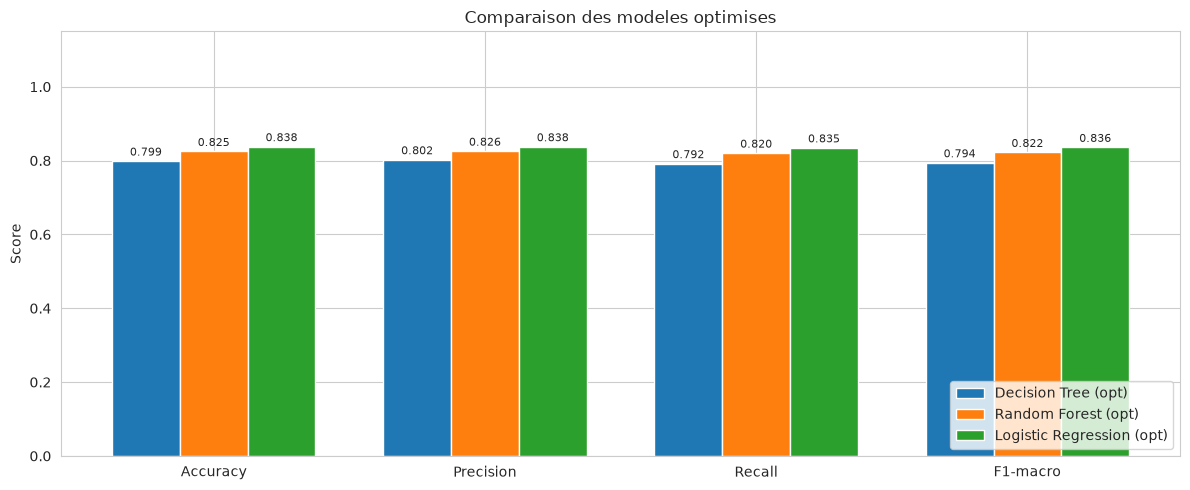

In [76]:
metrics = ["Accuracy", "Precision", "Recall", "F1-macro"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for idx, row in df_results.iterrows():
    offset = (list(df_results.index).index(idx) - 1) * width
    bars = ax.bar(x + offset, row[metrics].values, width, label=idx)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Comparaison des modeles optimises")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
# Identification automatique du meilleur modele (F1-macro)
best_name = df_results["F1-macro"].idxmax()
best_estimators = {
    "Decision Tree (opt)"       : gs_dt.best_estimator_,
    "Random Forest (opt)"       : rs_rf.best_estimator_,
    "Logistic Regression (opt)" : gs_lr.best_estimator_,
}
best_model = best_estimators[best_name]

import pandas as pd

# Conversion du rapport en DataFrame pour un rendu tableau soigné
report_dict = classification_report(
    Y_test,
    best_model.predict(X_test),
    zero_division=0,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()

print(f"Meilleur modele : {best_name}\n")
display(df_report)

Meilleur modele : Logistic Regression (opt)



,precision,recall,f1-score,support
0,0.454545,1.000000,0.625000,70.000000
1,0.000000,0.000000,0.000000,84.000000
accuracy,0.454545,0.454545,0.454545,0.454545
macro avg,0.227273,0.500000,0.312500,154.000000
weighted avg,0.206612,0.454545,0.284091,154.000000


---
## 9. Pipeline final : pretraitement + meilleur modele

On construit un  sklearn qui enchaine :
1. **StandardScaler** — standardisation des features
2. **Meilleur estimateur** — modele optimise

Le pipeline est ensuite sauvegarde en .

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib
import os

# Construction du pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  best_model)
])

# Re-entrainement sur les donnees brutes (non standardisees)
# pour que le scaler soit integre proprement dans le pipeline
pipeline.fit(X_train_resampled, y_train_resampled)

# Evaluation du pipeline sur le jeu de test
y_pred_pipeline = pipeline.predict(X_test)
print("Performance du Pipeline final sur X_test :")
print(f"  Accuracy : {accuracy_score(Y_test, y_pred_pipeline):.4f}")
print(f"  F1-macro : {f1_score(Y_test, y_pred_pipeline, average='macro', zero_division=0):.4f}")
print()
print(classification_report(Y_test, y_pred_pipeline, zero_division=0))

Performance du Pipeline final sur X_test :
  Accuracy : 0.8247
  F1-macro : 0.8225

              precision    recall  f1-score   support

           0       0.82      0.79      0.80        70
           1       0.83      0.86      0.84        84

    accuracy                           0.82       154
   macro avg       0.82      0.82      0.82       154
weighted avg       0.82      0.82      0.82       154



In [80]:
# Sauvegarde du pipeline
models_dir = os.path.join("..", "models")
os.makedirs(models_dir, exist_ok=True)

pipeline_path = os.path.join(models_dir, "pipeline_risque_diabete.pkl")
joblib.dump(pipeline, pipeline_path)
print(f"Pipeline sauvegarde : {pipeline_path}")

# Verification : rechargement et prediction test
pipeline_loaded = joblib.load(pipeline_path)
assert (pipeline_loaded.predict(X_test) == y_pred_pipeline).all(), "Erreur de rechargement !"
print("Rechargement verifie — les predictions sont identiques.")

# Resume du pipeline
print()
print("Resume du pipeline :")
print(pipeline)

Pipeline sauvegarde : ../models/pipeline_risque_diabete.pkl
Rechargement verifie — les predictions sont identiques.

Resume du pipeline :
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.1, max_iter=2000, penalty='l2',
                                    random_state=42))])
